Online Shopping Intention -
This project predicts whether an online shopping session will result in a purchase using machine learning.
Target variable: Revenue
0 → No purchase
1 → Purchase
This is a binary classification problem.

Exploratory Data Analysis

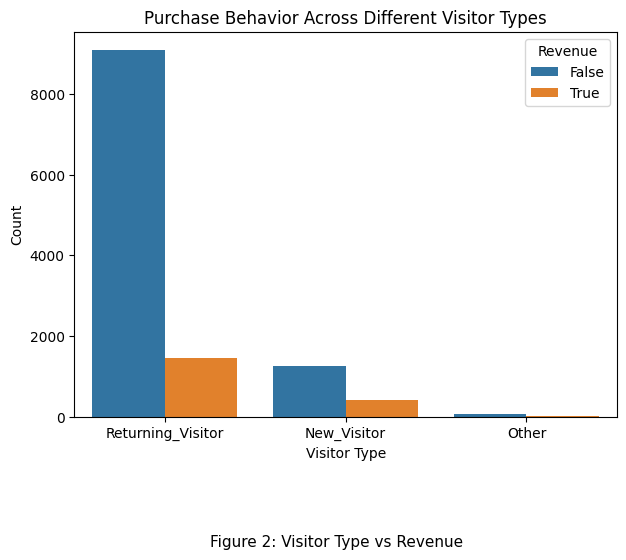


Visitor Type vs Revenue
The plot illustrates purchase behavior across different visitor types.
Returning visitors contribute to a higher number of purchases compared to new visitors.
This indicates that user familiarity and repeat visits strongly influence conversion probability.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('/content/online_shoppers_intention.csv')

# Visitor Type vs Revenue
plt.figure(figsize=(7,5))
sns.countplot(x='VisitorType', hue='Revenue', data=df)
plt.title("Purchase Behavior Across Different Visitor Types")
plt.xlabel("Visitor Type")
plt.ylabel("Count")
plt.legend(title="Revenue")
plt.figtext(0.5, -0.15, "Figure 2: Visitor Type vs Revenue", ha="center", fontsize=11)
plt.show()
print("\nVisitor Type vs Revenue")
print("The plot illustrates purchase behavior across different visitor types.")
print("Returning visitors contribute to a higher number of purchases compared to new visitors.")
print("This indicates that user familiarity and repeat visits strongly influence conversion probability.")

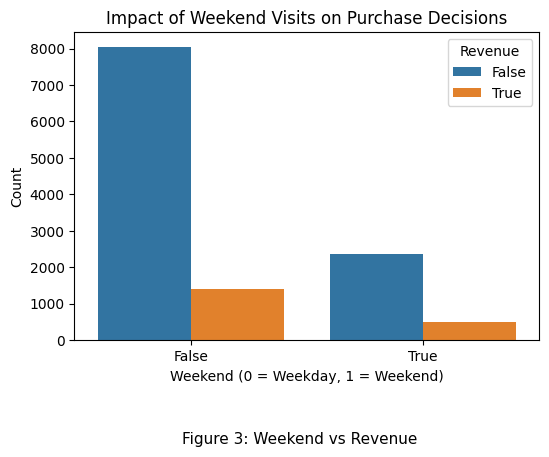


Weekend vs Revenue
This figure compares purchase behavior on weekdays and weekends.
Purchases are slightly higher during weekends, suggesting users have more time to browse and shop.
Temporal factors such as weekends play a role in online purchasing decisions.


In [ ]:
# Weekend vs Revenue
plt.figure(figsize=(6,4))
sns.countplot(x='Weekend', hue='Revenue', data=df)
plt.title("Impact of Weekend Visits on Purchase Decisions")
plt.xlabel("Weekend (0 = Weekday, 1 = Weekend)")
plt.ylabel("Count")
plt.figtext(0.5, -0.15, "Figure 3: Weekend vs Revenue", ha="center", fontsize=11)
plt.show()
print("\nWeekend vs Revenue")
print("This figure compares purchase behavior on weekdays and weekends.")
print("Purchases are slightly higher during weekends, suggesting users have more time to browse and shop.")
print("Temporal factors such as weekends play a role in online purchasing decisions.")

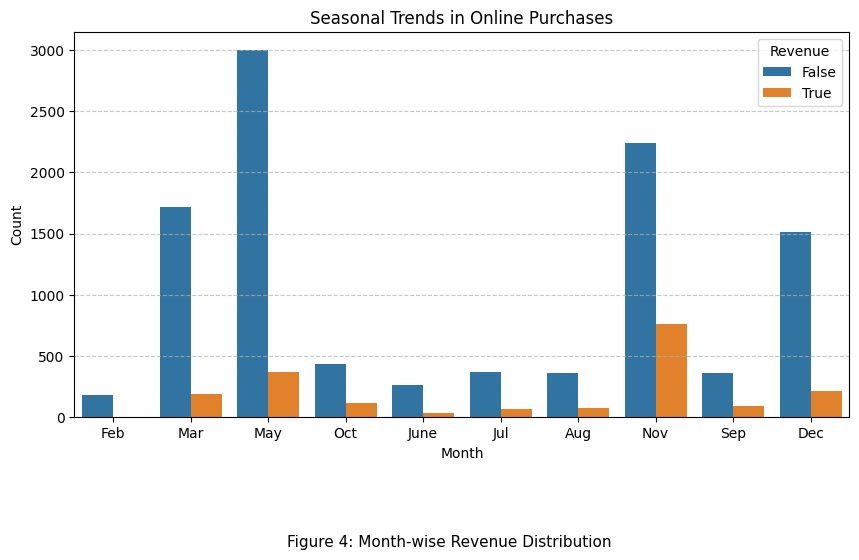


Month-wise Revenue Distribution
The month-wise plot highlights seasonal trends in online shopping behavior.
Certain months show increased purchasing activity, indicating seasonality effects.
This suggests that time-based features are important for predicting purchase intent.


In [ ]:
# Month-wise Revenue Distribution
plt.figure(figsize=(10,5))
sns.countplot(x='Month', hue='Revenue', data=df)
plt.title("Seasonal Trends in Online Purchases")
plt.xlabel("Month")
plt.ylabel("Count")
plt.grid(axis='y', linestyle='--', alpha=0.7, zorder=0)
plt.figtext(0.5, -0.15, "Figure 4: Month-wise Revenue Distribution", ha="center", fontsize=11)
plt.show()
print("\nMonth-wise Revenue Distribution")
print("The month-wise plot highlights seasonal trends in online shopping behavior.")
print("Certain months show increased purchasing activity, indicating seasonality effects.")
print("This suggests that time-based features are important for predicting purchase intent.")

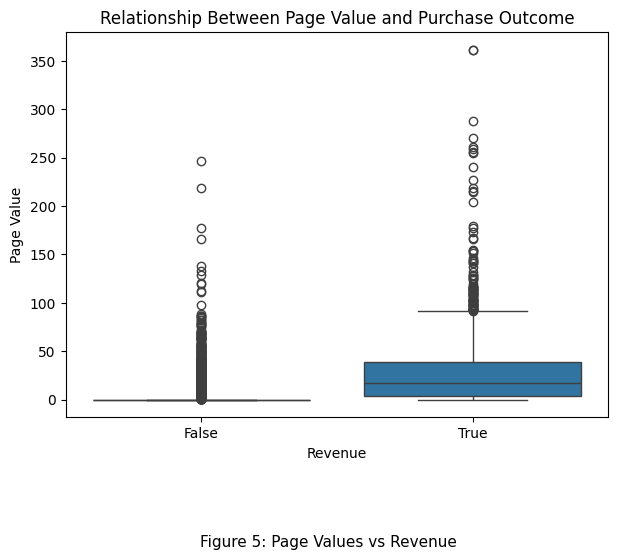


Page Values vs Revenue
This boxplot shows the relationship between page value and purchase outcome.
Sessions that result in purchases have significantly higher page values.
PageValues is a strong indicator of user intent and engagement.


In [ ]:
# Page Values vs Revenue
plt.figure(figsize=(7,5))
sns.boxplot(x='Revenue', y='PageValues', data=df) # shows pagevalues is higher for buyers
plt.title("Relationship Between Page Value and Purchase Outcome")
plt.xlabel("Revenue")
plt.ylabel("Page Value")
plt.figtext(0.5, -0.15, "Figure 5: Page Values vs Revenue", ha="center", fontsize=11)
plt.show()
print("\nPage Values vs Revenue")
print("This boxplot shows the relationship between page value and purchase outcome.")
print("Sessions that result in purchases have significantly higher page values.")
print("PageValues is a strong indicator of user intent and engagement.")

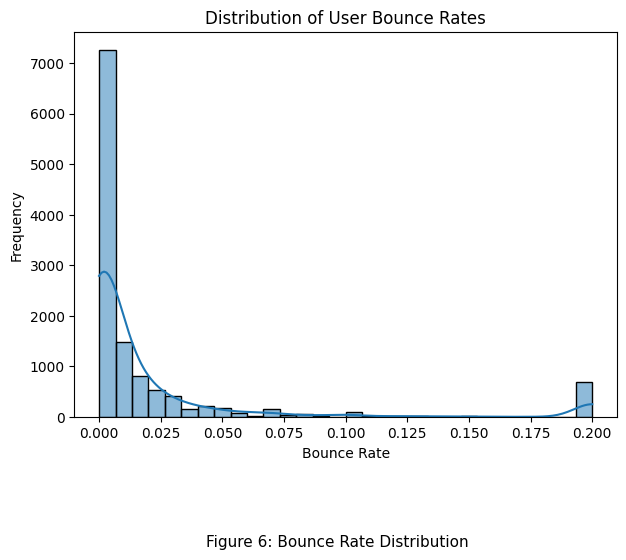


Bounce Rate Distribution
The distribution shows that most sessions have low bounce rates.
Higher bounce rates generally indicate poor engagement and reduced purchase likelihood.
Bounce rate reflects the quality of user interaction with the website.


In [ ]:
# Bounce Rate Distribution
plt.figure(figsize=(7,5))
sns.histplot(df['BounceRates'], bins=30, kde=True) #shows distribution of bounce rate
plt.title("Distribution of User Bounce Rates")
plt.xlabel("Bounce Rate")
plt.ylabel("Frequency")
plt.figtext(0.5, -0.15, "Figure 6: Bounce Rate Distribution", ha="center", fontsize=11)
plt.show()
print("\nBounce Rate Distribution")
print("The distribution shows that most sessions have low bounce rates.")
print("Higher bounce rates generally indicate poor engagement and reduced purchase likelihood.")
print("Bounce rate reflects the quality of user interaction with the website.")

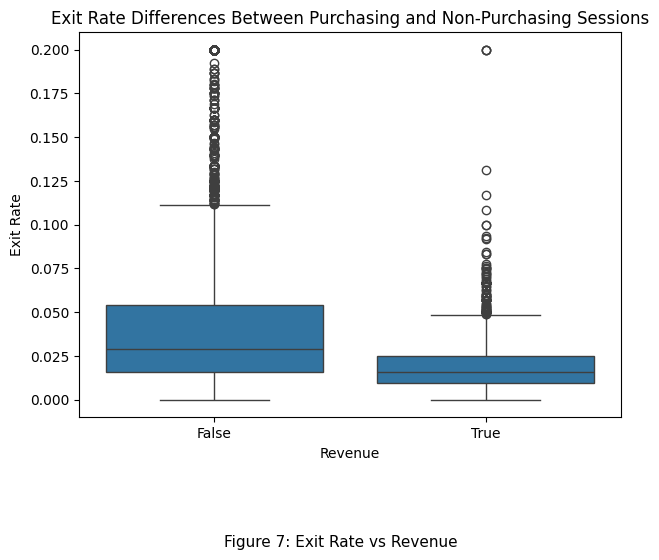


Exit Rate vs Revenue
This figure compares exit rates for purchasing and non-purchasing sessions.
Non-purchasing sessions tend to have higher exit rates.
Lower exit rates are associated with successful conversions.


In [ ]:
# Exit Rate vs Revenue
plt.figure(figsize=(7,5))
sns.boxplot(x='Revenue', y='ExitRates', data=df)
plt.title("Exit Rate Differences Between Purchasing and Non-Purchasing Sessions")
plt.xlabel("Revenue")
plt.ylabel("Exit Rate")
plt.figtext(0.5, -0.15, "Figure 7: Exit Rate vs Revenue", ha="center", fontsize=11)
plt.show()
print("\nExit Rate vs Revenue")
print("This figure compares exit rates for purchasing and non-purchasing sessions.")
print("Non-purchasing sessions tend to have higher exit rates.")
print("Lower exit rates are associated with successful conversions.")

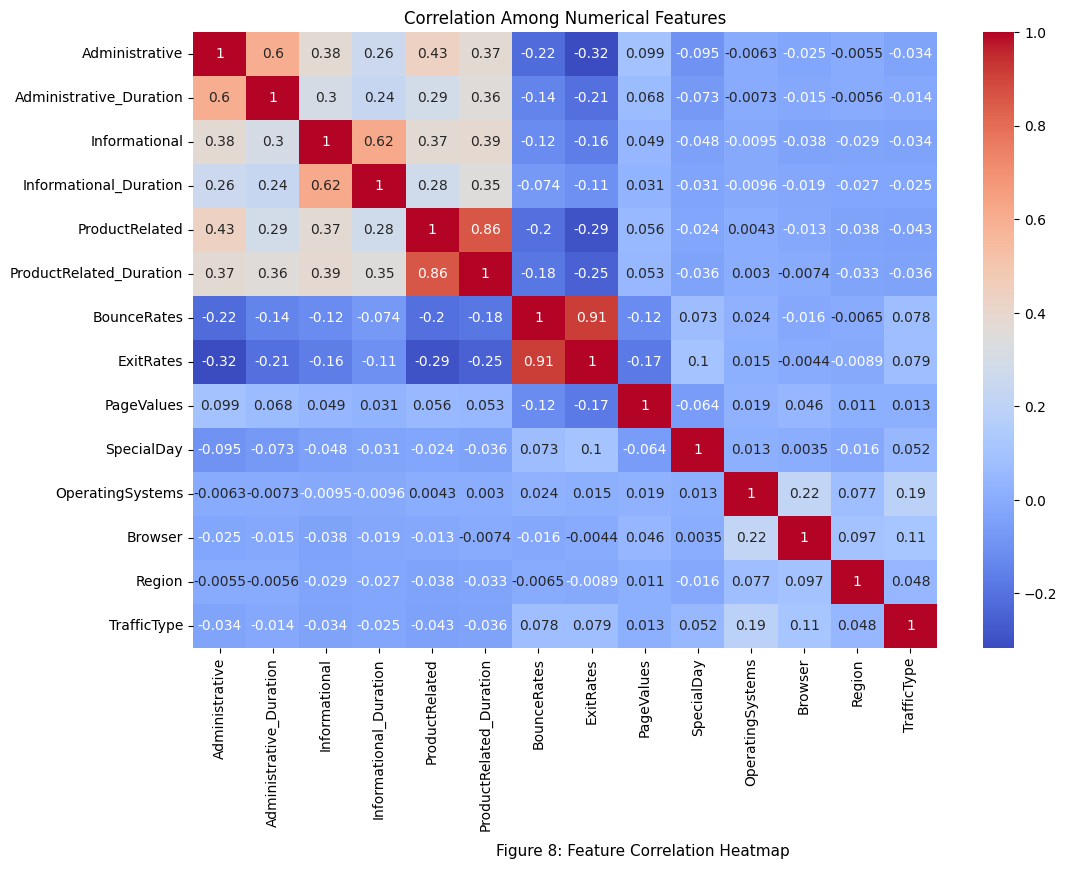


Feature Correlation Heatmap (Numerical Features)
The heatmap visualizes correlations among numerical features.
PageValues shows a strong positive correlation with Revenue.
The heatmap helps identify influential and redundant features in the dataset.


In [ ]:
# Correlation Heatmap
numeric_df = df.select_dtypes(include=['int64', 'float64'])

plt.figure(figsize=(12,8))
sns.heatmap(numeric_df.corr(), cmap='coolwarm', annot=True) #correlation b/w features
plt.title("Correlation Among Numerical Features")
plt.figtext(0.5, -0.15, "Figure 8: Feature Correlation Heatmap", ha="center", fontsize=11)
plt.show()
print("\nFeature Correlation Heatmap (Numerical Features)")
print("The heatmap visualizes correlations among numerical features.")
print("PageValues shows a strong positive correlation with Revenue.")
print("The heatmap helps identify influential and redundant features in the dataset.")


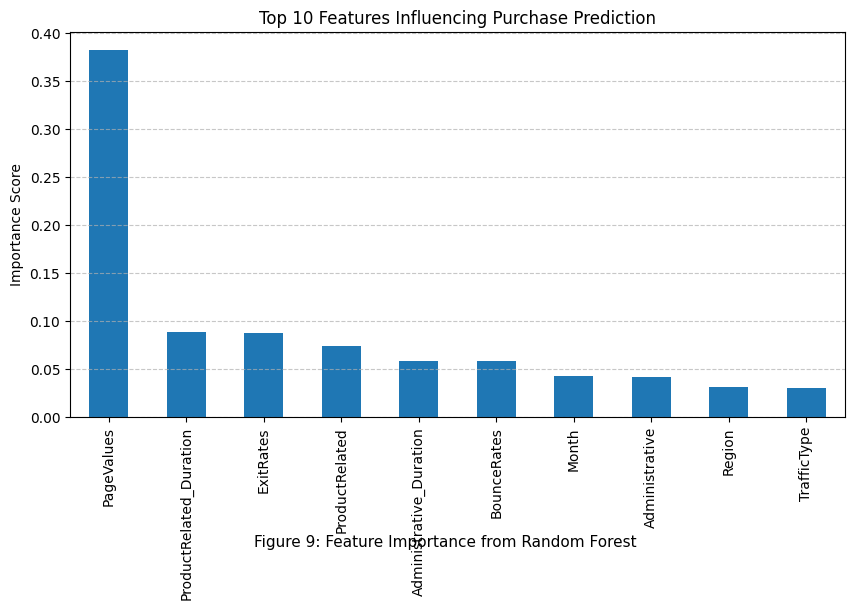


Feature Importance from Random Forest
This bar chart displays the top features influencing purchase prediction.
PageValues, ExitRates, and ProductRelated features have the highest importance.
Tree-based models effectively capture non-linear user behavior patterns.

The exploratory analysis reveals that user engagement metrics such as PageValues, ExitRates, and visitor behavior play a crucial role in predicting purchase intent.
Seasonal and temporal factors also influence conversion rates. These insights guide feature selection and model choice in the predictive modeling phase.


In [ ]:
# Feature Importance (Random Forest)
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier

df_encoded = df.copy()
le = LabelEncoder()
df_encoded['Month'] = le.fit_transform(df_encoded['Month'])
df_encoded['VisitorType'] = le.fit_transform(df_encoded['VisitorType'])
df_encoded['Weekend'] = df_encoded['Weekend'].astype(int)

X = df_encoded.drop('Revenue', axis=1)
y = df_encoded['Revenue']

rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X, y)

importance = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False) #shows which feature influence prediction most

plt.figure(figsize=(10,5))
importance.head(10).plot(kind='bar')
plt.title("Top 10 Features Influencing Purchase Prediction")
plt.ylabel("Importance Score")
plt.grid(axis='y', linestyle='--', alpha=0.7, zorder=0)
plt.figtext(0.5, -0.15, "Figure 9: Feature Importance from Random Forest", ha="center", fontsize=11)
plt.show()
print("\nFeature Importance from Random Forest")
print("This bar chart displays the top features influencing purchase prediction.")
print("PageValues, ExitRates, and ProductRelated features have the highest importance.")
print("Tree-based models effectively capture non-linear user behavior patterns.")

print("\nThe exploratory analysis reveals that user engagement metrics such as PageValues, ExitRates, and visitor behavior play a crucial role in predicting purchase intent.")
print("Seasonal and temporal factors also influence conversion rates. These insights guide feature selection and model choice in the predictive modeling phase.")

full project

In [13]:
!pip install xgboost

In [46]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_curve, roc_auc_score

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier

df = pd.read_csv('online_shoppers_intention.csv')
print("Shape of dataset:", df.shape)
print(df.head(3))
print("\nColumns:\n", df.columns)

Shape of dataset: (12330, 18)
   Administrative  Administrative_Duration  Informational  \
0               0                      0.0              0   
1               0                      0.0              0   
2               0                      0.0              0   

   Informational_Duration  ProductRelated  ProductRelated_Duration  \
0                     0.0               1                      0.0   
1                     0.0               2                     64.0   
2                     0.0               1                      0.0   

   BounceRates  ExitRates  PageValues  SpecialDay Month  OperatingSystems  \
0          0.2        0.2         0.0         0.0   Feb                 1   
1          0.0        0.1         0.0         0.0   Feb                 2   
2          0.2        0.2         0.0         0.0   Feb                 4   

   Browser  Region  TrafficType        VisitorType  Weekend  Revenue  
0        1       1            1  Returning_Visitor    False    F

In [47]:
# DATA CLEANING & PREPROCESSING
df = df.drop_duplicates()
df['Revenue'] = df['Revenue'].astype(int)
le = LabelEncoder()
df['Month'] = le.fit_transform(df['Month'])
df['VisitorType'] = le.fit_transform(df['VisitorType'])
df['Weekend'] = df['Weekend'].astype(int)

# FEATURE ENGINEERING
df["TotalDuration"] = (
    df["Administrative_Duration"]
    + df["Informational_Duration"]
    + df["ProductRelated_Duration"])

df["TotalPages"] = (
    df["Administrative"]
    + df["Informational"]
    + df["ProductRelated"])

df["BounceExitDiff"] = df["ExitRates"] - df["BounceRates"]
df["PageValuePerProduct"] = df["PageValues"] / (df["ProductRelated"] + 1)

# FEATURE & TARGET SPLIT
X = df.drop('Revenue', axis=1)
y = df['Revenue']
print("\nOriginal Class Distribution:")
print(y.value_counts())
print("\nFeatures shape:", X.shape)
print("Target shape:", y.shape)


Original Class Distribution:
Revenue
0    10297
1     1908
Name: count, dtype: int64

Features shape: (12205, 21)
Target shape: (12205,)


In [48]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# FEATURE SCALING
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# APPLY SMOTE (BALANCING)
smote = SMOTE(random_state=42)
X_train, y_train = smote.fit_resample(X_train, y_train)
print("\nBalanced Class Distribution After SMOTE:")
print(pd.Series(y_train).value_counts())


Balanced Class Distribution After SMOTE:
Revenue
1    8238
0    8238
Name: count, dtype: int64


In [49]:
# MODEL EVALUATION FUNCTION
def evaluate_model(model, X_train, X_test, y_train, y_test, model_name):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    # Print classification report
    print(f"\n{model_name} Classification Report\n")
    print(classification_report(y_test, y_pred))
    # Accuracy
    acc = accuracy_score(y_test, y_pred)
    print(f"{model_name} Accuracy:", acc)
    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f"Confusion Matrix - {model_name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()
    # ROC Curve
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)[:,1]
    else:
        y_prob = model.decision_function(X_test)

    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)

    return acc, fpr, tpr, auc


Logistic Regression Classification Report

              precision    recall  f1-score   support

           0       0.95      0.89      0.92      2059
           1       0.57      0.76      0.65       382

    accuracy                           0.87      2441
   macro avg       0.76      0.82      0.78      2441
weighted avg       0.89      0.87      0.88      2441

Logistic Regression Accuracy: 0.8713641950020483


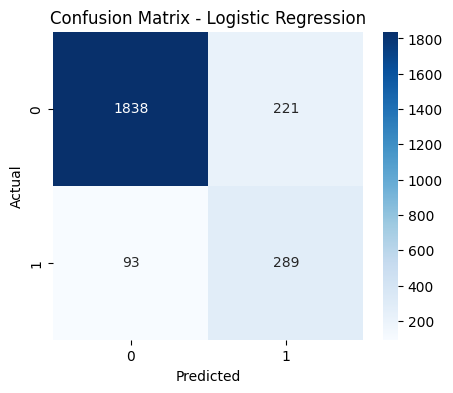


Random Forest Classification Report

              precision    recall  f1-score   support

           0       0.95      0.92      0.94      2059
           1       0.64      0.74      0.68       382

    accuracy                           0.89      2441
   macro avg       0.79      0.83      0.81      2441
weighted avg       0.90      0.89      0.90      2441

Random Forest Accuracy: 0.8926669397787792


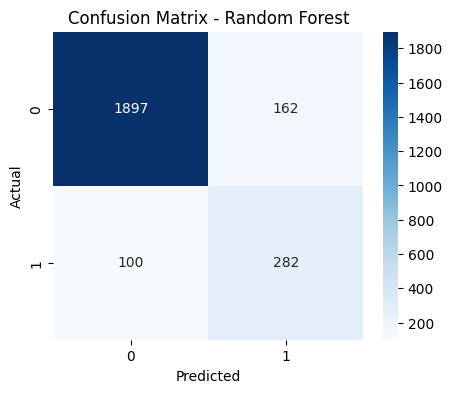


Support Vector Machine Classification Report

              precision    recall  f1-score   support

           0       0.95      0.89      0.92      2059
           1       0.55      0.74      0.63       382

    accuracy                           0.87      2441
   macro avg       0.75      0.81      0.78      2441
weighted avg       0.89      0.87      0.87      2441

Support Vector Machine Accuracy: 0.8660385088078656


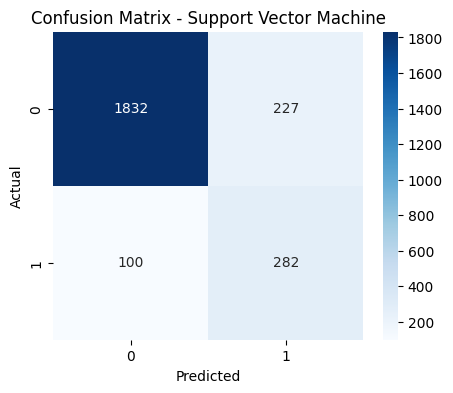


K-Nearest Neighbors Classification Report

              precision    recall  f1-score   support

           0       0.94      0.80      0.86      2059
           1       0.40      0.72      0.51       382

    accuracy                           0.79      2441
   macro avg       0.67      0.76      0.69      2441
weighted avg       0.85      0.79      0.81      2441

K-Nearest Neighbors Accuracy: 0.7873822204014748


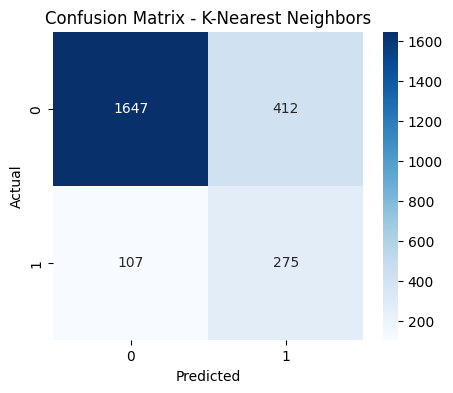


Decision Tree Classification Report

              precision    recall  f1-score   support

           0       0.93      0.90      0.92      2059
           1       0.54      0.66      0.60       382

    accuracy                           0.86      2441
   macro avg       0.74      0.78      0.76      2441
weighted avg       0.87      0.86      0.87      2441

Decision Tree Accuracy: 0.8603031544448996


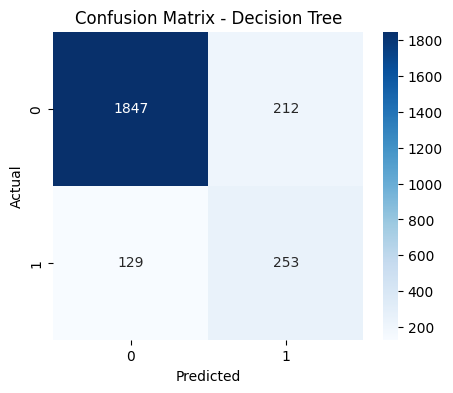


Gradient Boosting Classification Report

              precision    recall  f1-score   support

           0       0.95      0.93      0.94      2059
           1       0.65      0.73      0.69       382

    accuracy                           0.90      2441
   macro avg       0.80      0.83      0.81      2441
weighted avg       0.90      0.90      0.90      2441

Gradient Boosting Accuracy: 0.8975829578041786


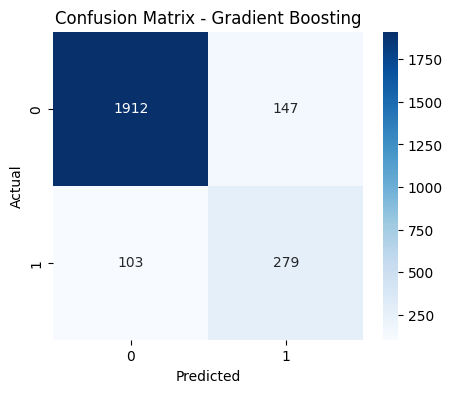


XGBoost Classification Report

              precision    recall  f1-score   support

           0       0.94      0.94      0.94      2059
           1       0.66      0.66      0.66       382

    accuracy                           0.89      2441
   macro avg       0.80      0.80      0.80      2441
weighted avg       0.89      0.89      0.89      2441

XGBoost Accuracy: 0.8943056124539124


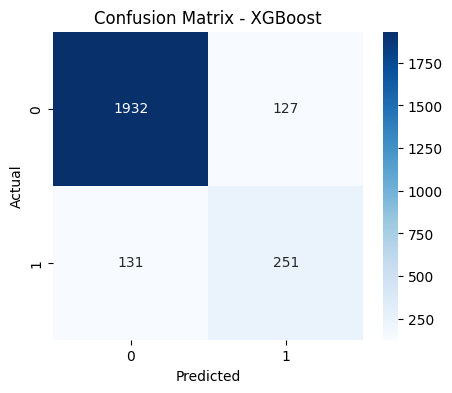

In [50]:
# TRAIN & COMPARE MODELS
results = {}

# Logistic Regression
lr = LogisticRegression(max_iter=1000)   # max_iter = maximum number of iterations
results["Logistic Regression"] = evaluate_model(
    lr, X_train, X_test, y_train, y_test, "Logistic Regression")

# Random Forest
rf = RandomForestClassifier(n_estimators=200, random_state=42)   # 200 trees
results["Random Forest"] = evaluate_model(
    rf, X_train, X_test, y_train, y_test, "Random Forest")

# Support Vector Machine
svm = SVC(kernel="rbf", probability=True)   # rbf kernel handles non-linear patterns
results["Support Vector Machine"] = evaluate_model(
    svm, X_train, X_test, y_train, y_test, "Support Vector Machine")

# K-Nearest Neighbors
knn = KNeighborsClassifier(n_neighbors=5)   # uses 5 nearest neighbors
results["K-Nearest Neighbors"] = evaluate_model(
    knn, X_train, X_test, y_train, y_test, "K-Nearest Neighbors")

# Decision Tree
dt = DecisionTreeClassifier(random_state=42)
results["Decision Tree"] = evaluate_model(
    dt, X_train, X_test, y_train, y_test, "Decision Tree")

# Gradient Boosting
gb = GradientBoostingClassifier()
results["Gradient Boosting"] = evaluate_model(
    gb, X_train, X_test, y_train, y_test, "Gradient Boosting")

# XGBoost
xgb = XGBClassifier(eval_metric="logloss")
results["XGBoost"] = evaluate_model(
    xgb, X_train, X_test, y_train, y_test, "XGBoost")


Model Comparison

                    Model  Accuracy   ROC_AUC
0     Logistic Regression  0.871364  0.898077
1           Random Forest  0.892667  0.925395
2  Support Vector Machine  0.866039  0.890848
3     K-Nearest Neighbors  0.787382  0.813678
4           Decision Tree  0.860303  0.779671
5       Gradient Boosting  0.897583  0.934747
6                 XGBoost  0.894306  0.927538


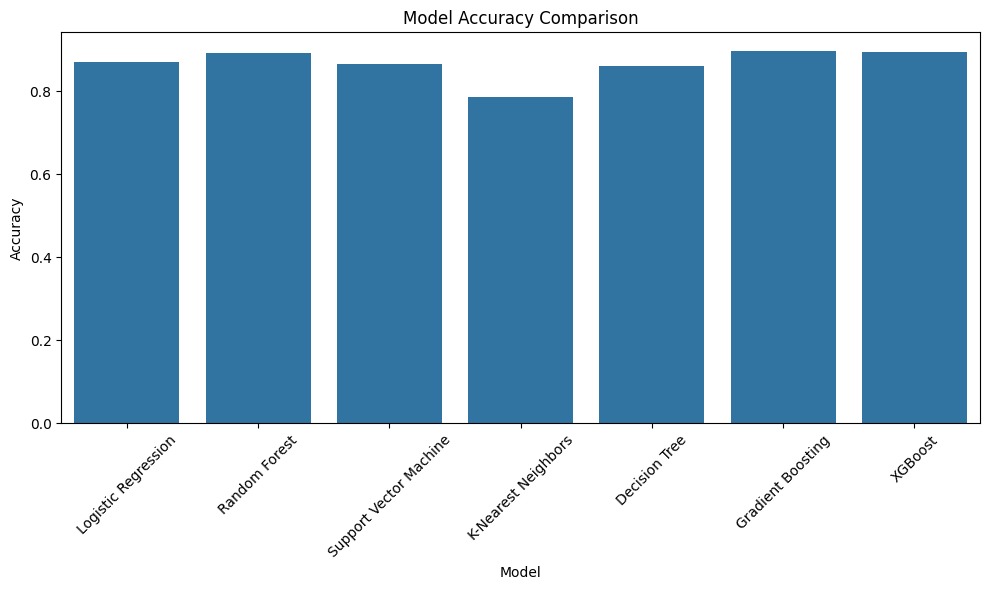

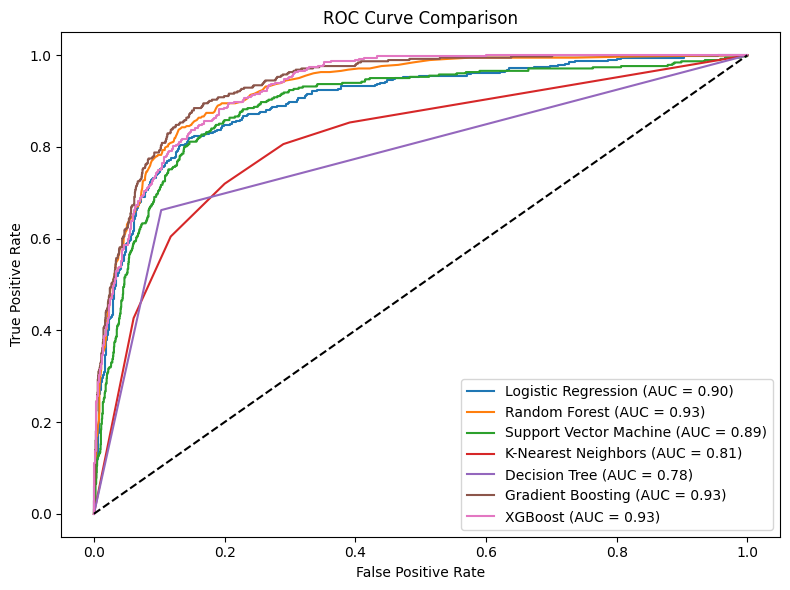

In [51]:
# MODEL COMPARISON TABLE
model_comparison = pd.DataFrame({
    "Model": results.keys(),
    "Accuracy": [results[m][0] for m in results],
    "ROC_AUC": [results[m][3] for m in results]})
print("\nModel Comparison\n")
print(model_comparison)

# ACCURACY BAR PLOT
plt.figure(figsize=(10,6))
sns.barplot(x="Model", y="Accuracy", data=model_comparison)
plt.title("Model Accuracy Comparison")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# ROC CURVE
plt.figure(figsize=(8,6))
for name, (_, fpr, tpr, auc) in results.items():
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.2f})")
plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.tight_layout()
plt.show()